<a href="https://colab.research.google.com/github/Izabelladesign/171FinalProj/blob/Data-Exploration-%26-Preprocessing/CoralClassification_CustomCNN_5k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coral classification — custom CNN (5k training images)
Since we got a lower accuracy with our original CNN, we wanted to increase the number of images and use a different split to see if we can get the accuracy higher.


In [ ]:
!pip install -q kagglehub scikit-learn seaborn

In [ ]:
from pathlib import Path
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
TRAIN_RATIO = 0.85        # combined-and-resplit: 85% train / 10% val / 5% test
VAL_RATIO   = 0.10
TEST_RATIO  = 0.05
MAX_TRAIN_IMAGES = 5000   # stratified cap on training rows; None = use full 85% train split
CNN_EPOCHS = 80           # custom CNN (EarlyStopping can stop earlier)
SEED = 42
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [ ]:
# Download dataset from Kaggle
import kagglehub
download_path = Path(kagglehub.dataset_download("aneeshdighe/corals-classification"))
print("kagglehub path:", download_path)


100%|██████████| 134M/134M [00:01<00:00, 110MB/s]

Extracting files...


kagglehub path: /root/.cache/kagglehub/datasets/aneeshdighe/corals-classification/versions/1


In [ ]:
# Auto-find the folder that contains Training / Validation / Testing
def find_dataset_root(start: Path):
    for root, dirs, _ in os.walk(start):
        if {"Training", "Validation", "Testing"}.issubset(set(dirs)):
            return Path(root)
    return None

data_directory = find_dataset_root(download_path)
if data_directory is None:
    raise FileNotFoundError(
        f"Could not find Training/Validation/Testing folders inside {download_path}."
    )

training   = data_directory / "Training"
validation = data_directory / "Validation"
testing    = data_directory / "Testing"

print("Train:", training)
print("Valid:", validation)
print("Test :", testing)


Train: /root/.cache/kagglehub/datasets/aneeshdighe/corals-classification/versions/1/Bleached Corals and Healthy Corals Classification/Training
Valid: /root/.cache/kagglehub/datasets/aneeshdighe/corals-classification/versions/1/Bleached Corals and Healthy Corals Classification/Validation
Test : /root/.cache/kagglehub/datasets/aneeshdighe/corals-classification/versions/1/Bleached Corals and Healthy Corals Classification/Testing


In [ ]:
# Helpers: build labeled DataFrame, take a stratified subset, build Keras generators

def make_image_df(root_dir):
    rows = []
    class_names = sorted([p.name for p in root_dir.iterdir() if p.is_dir()])
    for class_name in class_names:
        class_dir = root_dir / class_name
        for fp in class_dir.iterdir():
            if fp.suffix.lower() in IMAGE_EXTS:
                rows.append((str(fp), class_name))
    df = pd.DataFrame(rows, columns=["filepath", "label"])
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


def take_stratified_subset(df, n_samples):
    if n_samples is None or n_samples >= len(df):
        return df.reset_index(drop=True)
    subset, _ = train_test_split(df, train_size=n_samples, stratify=df["label"], random_state=SEED)
    return subset.reset_index(drop=True)


def make_generators(train_df, valid_df, test_df):
    classes = sorted(train_df["label"].unique())

    train_aug = ImageDataGenerator(
        rescale=1.0 / 255,
        horizontal_flip=True,
        vertical_flip=True,
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.10,
        height_shift_range=0.10,
        brightness_range=(0.9, 1.1),
        fill_mode="nearest",
    )
    eval_gen = ImageDataGenerator(rescale=1.0 / 255)

    train_gen = train_aug.flow_from_dataframe(
        train_df, x_col="filepath", y_col="label",
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="binary", classes=classes, shuffle=True, seed=SEED,
    )
    valid_gen = eval_gen.flow_from_dataframe(
        valid_df, x_col="filepath", y_col="label",
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="binary", classes=classes, shuffle=False,
    )
    test_gen = eval_gen.flow_from_dataframe(
        test_df, x_col="filepath", y_col="label",
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="binary", classes=classes, shuffle=False,
    )
    return train_gen, valid_gen, test_gen


## Data exploration


Image counts by split:
Train: 7384
Valid: 985
Test : 923

Train class counts:
label
bleached_corals    3880
healthy_corals     3504
Name: count, dtype: int64

Validation class counts:
label
healthy_corals     500
bleached_corals    485
Name: count, dtype: int64

Test class counts:
label
bleached_corals    485
healthy_corals     438
Name: count, dtype: int64


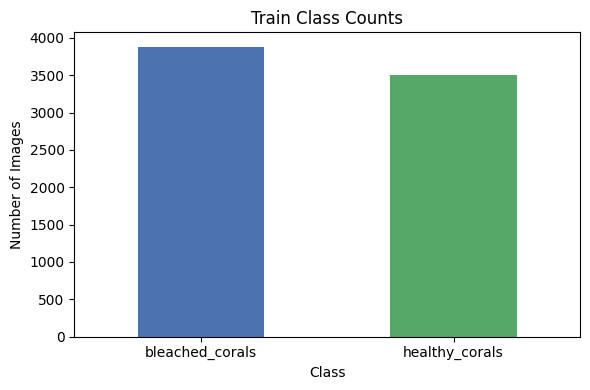

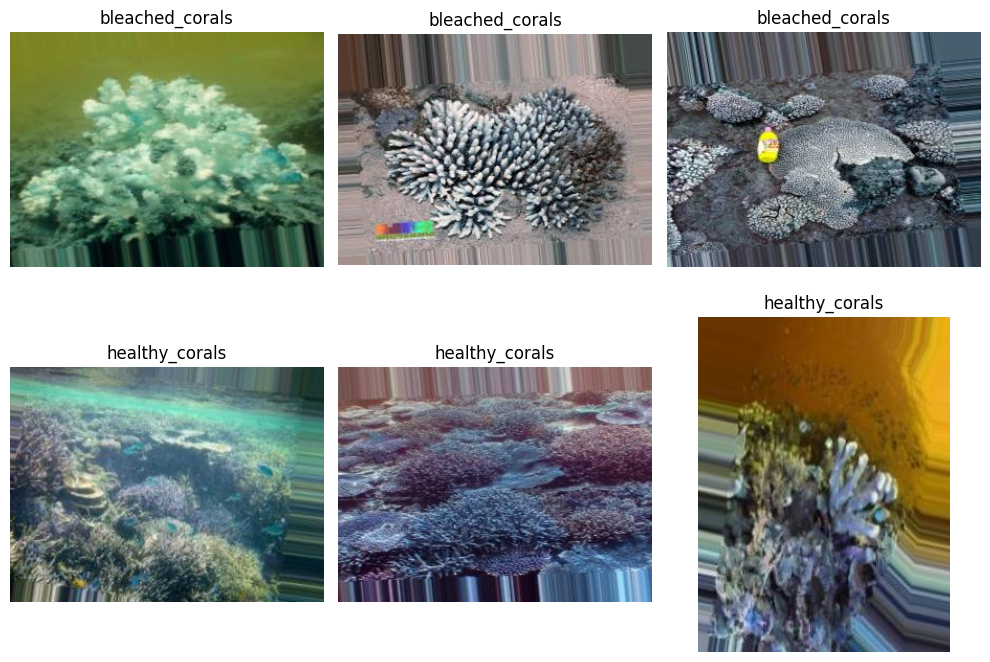

In [ ]:
# Build full DataFrames for each split and inspect class counts
train_df_full = make_image_df(training)
valid_df_full = make_image_df(validation)
test_df_full  = make_image_df(testing)

print("Image counts by split:")
print(f"Train: {len(train_df_full)}")
print(f"Valid: {len(valid_df_full)}")
print(f"Test : {len(test_df_full)}")

print("\nTrain class counts:")
print(train_df_full["label"].value_counts())
print("\nValidation class counts:")
print(valid_df_full["label"].value_counts())
print("\nTest class counts:")
print(test_df_full["label"].value_counts())

# Class count plot
train_df_full["label"].value_counts().sort_index().plot(
    kind="bar", figsize=(6, 4), color=["#4C72B0", "#55A868"]
)
plt.title("Train Class Counts"); plt.xlabel("Class"); plt.ylabel("Number of Images")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

# Sample images
sample_rows = train_df_full.sample(n=min(6, len(train_df_full)), random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()
for i, row in sample_rows.iterrows():
    axes[i].imshow(plt.imread(row["filepath"]))
    axes[i].set_title(row["label"]); axes[i].axis("off")
for j in range(len(sample_rows), len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()


## Preprocessing and data split

- 224×224 resize; pixels rescaled to [0, 1]
- Training-only augmentation (flips, rotation, zoom, shift, brightness); validation/test only rescaling
- Combine all images (original Training + Validation + Testing), stratified **85% / 10% / 5%** train / val / test
- **Cap training** at `MAX_TRAIN_IMAGES` (5,000) with stratified sampling; val/test stay full split sizes


In [ ]:
# Combine every image from the original Training / Validation / Testing folders,
# then stratified 85% / 10% / 5% train / validation / test.
# Finally cap training rows at MAX_TRAIN_IMAGES (stratified) for faster runs.
combined_df = pd.concat([train_df_full, valid_df_full, test_df_full], ignore_index=True)
combined_df = combined_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

train_df, temp_df = train_test_split(
    combined_df,
    train_size=TRAIN_RATIO,
    stratify=combined_df["label"],
    random_state=SEED,
)
val_share = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
valid_df, test_df = train_test_split(
    temp_df,
    train_size=val_share,
    stratify=temp_df["label"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

train_df = take_stratified_subset(train_df, MAX_TRAIN_IMAGES)

print(f"Combined dataset size: {len(combined_df)}")
print(f"Training set size  : {len(train_df)}")
print(f"Validation set size: {len(valid_df)}")
print(f"Test set size      : {len(test_df)}")
print(train_df["label"].value_counts(normalize=True).rename("train_ratio"))

train_gen, valid_gen, test_gen = make_generators(train_df, valid_df, test_df)
print("\nClass indices:", train_gen.class_indices)
class_names = list(train_gen.class_indices.keys())


Combined dataset size: 9292
Training set size  : 5000
Validation set size: 929
Test set size      : 465
label
bleached_corals    0.522
healthy_corals     0.478
Name: train_ratio, dtype: float64
Found 5000 validated image filenames belonging to 2 classes.
Found 929 validated image filenames belonging to 2 classes.
Found 465 validated image filenames belonging to 2 classes.

Class indices: {'bleached_corals': 0, 'healthy_corals': 1}


## Custom CNN — training and evaluation

Adam + binary cross-entropy (label smoothing), early stopping, LR reduction on plateau, validation threshold tuning, and TTA on the test set.


In [ ]:
# Imports + evaluation helpers
import seaborn as sns
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


def tta_predict(model, df, n_aug=5, batch_size=BATCH_SIZE, seed=SEED):
    """Average predictions over n_aug augmented passes plus one clean pass."""
    clean = ImageDataGenerator(rescale=1.0 / 255).flow_from_dataframe(
        df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode="binary",
        classes=sorted(df["label"].unique()),
        shuffle=False,
    )
    probs = model.predict(clean, verbose=0).flatten()

    aug = ImageDataGenerator(
        rescale=1.0 / 255,
        horizontal_flip=True,
        rotation_range=15,
        zoom_range=0.10,
        width_shift_range=0.08,
        height_shift_range=0.08,
    )
    for i in range(n_aug):
        gen = aug.flow_from_dataframe(
            df,
            x_col="filepath",
            y_col="label",
            target_size=IMG_SIZE,
            batch_size=batch_size,
            class_mode="binary",
            classes=sorted(df["label"].unique()),
            shuffle=False,
            seed=seed + i,
        )
        probs += model.predict(gen, verbose=0).flatten()
    return probs / (n_aug + 1), clean.classes, list(clean.class_indices.keys()), clean.filepaths


def evaluate_and_plot(name, history_pairs, model, n_aug=5):
    history = pd.concat([pd.DataFrame(h) for _, h in history_pairs], ignore_index=True)
    phase1_end = len(history_pairs[0][1]["accuracy"]) if len(history_pairs) > 1 else None

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax_, metric in zip(axes, ["accuracy", "loss"]):
        ax_.plot(history[metric], label="Train")
        ax_.plot(history[f"val_{metric}"], label="Validation")
        if phase1_end is not None:
            ax_.axvline(x=phase1_end, color="gray", linestyle="--", label="Fine-tune start")
        ax_.set_title(f"{name} - {metric.capitalize()}")
        ax_.set_xlabel("Epoch")
        ax_.legend()
    plt.tight_layout()
    plt.show()

    val_probs, val_true, _, _ = tta_predict(model, valid_df, n_aug=n_aug)
    best_thr, best_acc = 0.5, 0.0
    for thr in np.linspace(0.1, 0.9, 81):
        a = accuracy_score(val_true, (val_probs > thr).astype(int))
        if a > best_acc:
            best_acc, best_thr = a, thr
    print(f"{name} best validation threshold (with TTA): {best_thr:.2f} (val acc={best_acc:.4f})")

    probs, true, classes, _ = tta_predict(model, test_df, n_aug=n_aug)
    preds = (probs > best_thr).astype(int)

    print(f"\n{name} - Test Results")
    print(f"Accuracy : {accuracy_score(true, preds):.4f}")
    print(f"Precision: {precision_score(true, preds):.4f}")
    print(f"Recall   : {recall_score(true, preds):.4f}")
    print(f"F1 Score : {f1_score(true, preds):.4f}")
    print(f"ROC AUC  : {roc_auc_score(true, probs):.4f}")
    print(classification_report(true, preds, target_names=classes))

    cm = confusion_matrix(true, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return probs, preds, true


### Architecture and train loop


In [ ]:
# Custom CNN architecture
# 4 conv blocks (32 / 64 / 128 / 256 filters) with BatchNorm + MaxPool + Dropout
# GlobalAveragePooling2D (replaces Flatten -> fewer params, less overfitting)
# Dense head with moderate dropout
# Sigmoid output (0 = bleached, 1 = healthy)
#
# Tuning notes (vs. the previous 0.77 run):
# - Lowered dropout in every block (the previous run was stuck around train acc
#   ~ val acc ~ 0.77, a classic underfitting signal from too much regularization).
# - Lowered the initial LR to 3e-4 and added label smoothing for steadier training.
# - Bumped EarlyStopping patience so the LR scheduler has room to step the LR down
#   twice before training is cut.

def build_custom_cnn():
    return models.Sequential([
        Input(shape=(224, 224, 3)),

        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.15),

        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.20),

        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Conv2D(256, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(256, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.40),
        layers.Dense(1, activation="sigmoid"),
    ])

from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.losses import BinaryCrossentropy

cnn_model = build_custom_cnn()
cnn_model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss=BinaryCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)
cnn_model.summary()
print(f"Total parameters: {cnn_model.count_params():,}")

cnn_history = cnn_model.fit(
    train_gen,
    epochs=CNN_EPOCHS,
    validation_data=valid_gen,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=18, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ],
    verbose=1,
)

cnn_probs, cnn_preds, cnn_true = evaluate_and_plot(
    "Custom CNN",
    [("train", cnn_history.history)],
    cnn_model,
    n_aug=5,
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,243,169 (4.74 MB)

 Trainable params: 1,240,737 (4.73 MB)

 Non-trainable params: 2,432 (9.50 KB)

Total parameters: 1,243,169
Epoch 1/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 125s 617ms/step - accuracy: 0.6678 - loss: 0.7214 - val_accuracy: 0.5221 - val_loss: 0.8250 - learning_rate: 3.0000e-04
Epoch 2/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 79s 504ms/step - accuracy: 0.6964 - loss: 0.6569 - val_accuracy: 0.5221 - val_loss: 2.1264 - learning_rate: 3.0000e-04
Epoch 3/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 516ms/step - accuracy: 0.7108 - loss: 0.6177 - val_accuracy: 0.6189 - val_loss: 0.7651 - learning_rate: 3.0000e-04
Epoch 4/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 512ms/step - accuracy: 0.7120 - loss: 0.6137 - val_accuracy: 0.6405 - val_loss: 0.9771 - learning_rate: 3.0000e-04
Epoch 5/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 79s 506ms/step - accuracy: 0.7278 - loss: 0.5992 - val_accuracy: 0.7234 - val_loss: 0.5977 - learning_rate: 3.0000e-04
Epoch 6/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 506ms/step - accuracy: 0.7320 - loss: 0.5787 - val_accuracy: 0.7417 - val_loss: 0.5440 - learning_rate: 3.0000e-04
Epoch 7/80
157/15